# The Student Data Journey — Part 1
## Understanding, Exploring, and Cleaning Real-World Data
### *The Maplewood High School Analytics Project*

---

> **The Story:** You've just been hired as a junior data scientist at *Maplewood High School*.
> The vice-principal drops a USB drive on your desk and says:
> *"We have 500 student records from last semester — grades, attendance, family background.
> Can you help us figure out who's at risk of failing before it's too late?"*
>
> The file is messy. There are missing values, weird outliers, and raw text no computer
> can read yet. Over **two notebooks**, you'll clean, transform, and model this data.
> **This is Part 1: Understanding and Cleaning.**

---

## Key Vocabulary

Before we start, here are the technical words you'll encounter — explained simply:

| Term | Simple Explanation |
|------|-------------------|
| **Dataset** | A table of information — like a spreadsheet with rows and columns |
| **Object / Instance** | One row in the table — in our case, one student |
| **Feature / Attribute** | One column — a piece of info about each student (e.g., study hours) |
| **Target Variable** | The thing we want to predict — the student's final grade |
| **Pattern Recognition** | Spotting repeated structures in data that tell a story |
| **Supervised Learning** | Training a model using examples where we already know the answer |
| **Unsupervised Learning** | Finding hidden groups or patterns without knowing answers upfront |
| **Data Engineering** | The full pipeline: collecting, cleaning, and organizing data |
| **Outlier** | A value far from the rest — suspiciously high or low |
| **Missing Value** | A blank cell — information we simply don't have |
| **Sampling** | Picking a smaller group to represent the full population |

## What You'll Learn in Part 1

1. What **pattern recognition** looks like in real student data
2. The difference between **supervised** and **unsupervised** learning
3. The **data engineering lifecycle** — 6 stages from raw data to insight
4. What **attributes, features, and objects** mean (with our dataset as the example)
5. How to calculate **mean, standard deviation, mode, variance, and quartiles**
6. How to identify three types of **missing data**: MNAR, MCAR, and MAR
7. How to detect and handle **outliers** using the IQR method
8. How to take **random samples** with and without replacement
9. How **stratified sampling** preserves proportions across groups
10. How to use **regular expressions (regex)** to pull info from messy text
11. How **aggregation** compresses 500 rows into a clear summary

---
*We use a synthetic (generated) dataset of 500 students — designed so every concept*
*shows up clearly and no real student's data is used.*

In [1]:
# ──────────────────────────────────────────────────────────────────
# SETUP — Import all libraries
# Think of this like laying out every tool before starting a project.
# We gather everything we need FIRST so nothing interrupts us later.
# ──────────────────────────────────────────────────────────────────

import numpy as np               # fast math and array operations
import pandas as pd              # DataFrames — the spreadsheets of Python
import matplotlib.pyplot as plt  # creating charts
import seaborn as sns            # prettier statistical charts
import re                        # regular expressions
import warnings
warnings.filterwarnings('ignore')  # hide technical warnings to keep output readable

# random_state=42 means every 'random' choice produces the same result each run.
# This is called REPRODUCIBILITY — your teacher gets the same output as you.
np.random.seed(42)

sns.set_style('whitegrid')         # clean chart backgrounds
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Setup complete — all libraries loaded!')

Setup complete — all libraries loaded!


---
## Part 0: The Big Picture

### What Is Pattern Recognition?

Imagine looking at your school's exam results — 500 numbers on a page. Hard to read, right?
But if you plot them on a chart, something magical happens: **patterns emerge**.

You might notice:
- Students who study more tend to score higher
- Students who skip class a lot tend to fail
- Students from certain backgrounds score consistently different

**Pattern recognition** is the foundation of all data science. Before we build any model,
we look for these patterns — because they tell us WHERE the story is.

Let's create a preview of our data and see if we can spot patterns *before doing any analysis*.

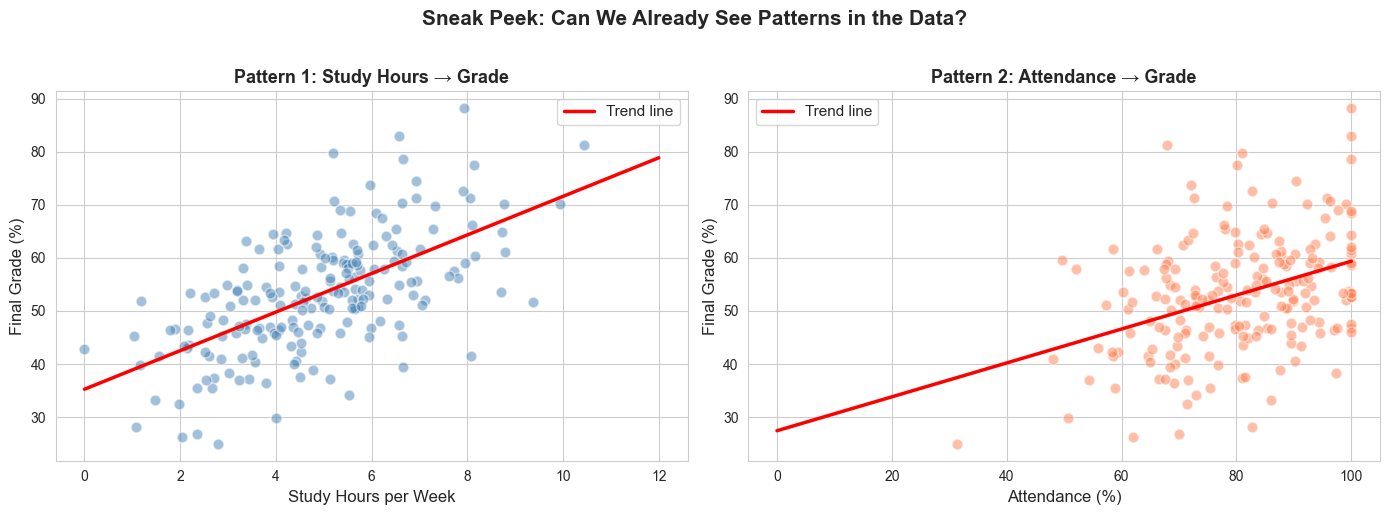

Both charts show an upward trend — students who study/attend more tend to score higher.
THAT is pattern recognition. We spotted a signal in the noise!


In [2]:
# ──────────────────────────────────────────────────────────────────
# PATTERN RECOGNITION — Sneak peek scatter plots
# We generate a small preview dataset just for this visualization.
# The FULL dataset comes in Part 1.
# ──────────────────────────────────────────────────────────────────

n_preview = 200
preview_study   = np.random.normal(5.0, 2.0, n_preview).clip(0, 12)
preview_attend  = np.random.normal(80,  15,   n_preview).clip(0, 100)
preview_noise   = np.random.normal(0,   8,    n_preview)
preview_grade   = (preview_study * 4 + preview_attend * 0.3 + preview_noise + 10).clip(0, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Study Hours vs Grade ──────────────────────────────────
axes[0].scatter(preview_study, preview_grade, alpha=0.5,
                color='steelblue', edgecolors='white', s=60)
trend1 = np.polyfit(preview_study, preview_grade, 1)
x_range = np.linspace(0, 12, 100)
axes[0].plot(x_range, np.polyval(trend1, x_range), 'r-', lw=2.5, label='Trend line')
axes[0].set_xlabel('Study Hours per Week', fontsize=12)
axes[0].set_ylabel('Final Grade (%)', fontsize=12)
axes[0].set_title('Pattern 1: Study Hours → Grade', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# ── Plot 2: Attendance vs Grade ───────────────────────────────────
axes[1].scatter(preview_attend, preview_grade, alpha=0.5,
                color='coral', edgecolors='white', s=60)
trend2 = np.polyfit(preview_attend, preview_grade, 1)
x_range2 = np.linspace(0, 100, 100)
axes[1].plot(x_range2, np.polyval(trend2, x_range2), 'r-', lw=2.5, label='Trend line')
axes[1].set_xlabel('Attendance (%)', fontsize=12)
axes[1].set_ylabel('Final Grade (%)', fontsize=12)
axes[1].set_title('Pattern 2: Attendance → Grade', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('Sneak Peek: Can We Already See Patterns in the Data?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Both charts show an upward trend — students who study/attend more tend to score higher.')
print('THAT is pattern recognition. We spotted a signal in the noise!')

**What do we see here?**

- Both scatter plots show an upward-sloping trend line — a clear **positive relationship**
- The relationship isn't perfect (some low-study students still score well), but the **trend is real**
- This is exactly what machine learning exploits: it finds these trends mathematically
  and uses them to make predictions

---

### Supervised vs. Unsupervised Learning

Now that we see patterns exist, HOW should a computer learn from them?
There are two main approaches:

---

#### Supervised Learning — "Learning with a Teacher"

Think of a driving instructor who sits beside you, watches everything you do,
and says *"turn here," "brake now," "that was a mistake."*
You learn by getting **feedback on labeled examples**.

In data science: we give the computer our 500 students with their **known final grades**.
The computer learns the pattern between *inputs* (study hours, attendance) and *output* (grade).
Then it can predict grades for **new students** it has never seen.

> **Our supervised task:** Predict a student's final grade from their features.

---

#### Unsupervised Learning — "Finding Groups on Your Own"

Imagine sorting a pile of 500 unsorted songs. Nobody tells you the categories.
But you naturally group them: *pop, rock, classical, jazz...*
You found structure **without labels**.

In data science: we give the computer the student data **without telling it the grades**.
It discovers natural groupings: *"high achievers," "average students," "at-risk students."*

> **Our unsupervised task (in Part 2):** Cluster students into groups based on similarity.

---

### The Data Engineering Lifecycle

Every data science project follows a pipeline — a series of steps that transform raw,
messy data into useful insights. Think of it like **processing raw ingredients into a meal**:

```
 Stage 1       Stage 2      Stage 3        Stage 4       Stage 5      Stage 6
┌──────────┐  ┌──────────┐  ┌──────────┐  ┌──────────┐  ┌──────────┐  ┌──────────┐
│ COLLECT  │→ │  CLEAN   │→ │TRANSFORM │→ │ EXPLORE  │→ │  MODEL   │→ │ INSIGHTS │
│          │  │          │  │          │  │  (EDA)   │  │          │  │          │
│ Gather   │  │ Fix      │  │ Normalize│  │ Charts & │  │ Train ML │  │ Present  │
│ raw data │  │ errors & │  │ Encode   │  │ stats    │  │ model    │  │ findings │
│          │  │ missing  │  │ Discretize│ │          │  │          │  │          │
└──────────┘  └──────────┘  └──────────┘  └──────────┘  └──────────┘  └──────────┘
  Part 1 ←────────────────────────────────────────────→  Part 2
```

**In this notebook (Part 1):** Stages 1–2 and part of Stage 4

**In Part 2:** Stages 3, 5, and 6

Every stage matters. Skipping cleaning means your model learns from bad data ("garbage in, garbage out").
Skipping exploration means you miss important patterns before modeling.

Let's begin at Stage 1: **Collecting our data.**

---

## Part 1: Meet the Dataset
### Attributes, Features, and Objects

In data science, we use three terms to describe the pieces of a dataset:

| Word | What It Means | Our Example |
|------|--------------|-------------|
| **Object** (or *instance*) | A single item being described — one row | One student |
| **Attribute** (or *feature*) | A property that describes the object — one column | `study_hours`, `gender` |
| **Value** | The actual content of one cell | `7.5` hours, `'Female'` |

Attributes come in two flavors:
- **Numerical** (numbers you can do math with): `study_hours`, `final_grade`
- **Categorical** (labels or categories): `gender`, `parent_education`

Now let's build our dataset. We generate 500 students with realistic values,
carefully designed so that `final_grade` genuinely correlates with the features.

In [3]:
# ──────────────────────────────────────────────────────────────────
# BUILD THE MAPLEWOOD HIGH SCHOOL DATASET
# We generate 500 synthetic students.
# 'Synthetic' means made-up but realistic — no real student's data is used.
# ──────────────────────────────────────────────────────────────────

N = 500  # total number of students

# ── Numerical Attributes ──────────────────────────────────────────
# np.random.normal(mean, std_dev, N) creates N values around a central point
# .clip(min, max) prevents unrealistic values (e.g., -2 study hours)

study_hours     = np.random.normal(5.0, 2.0, N).clip(0, 12)   # hours studied per week
attendance_pct  = np.random.normal(80,  15,   N).clip(0, 100)  # % of classes attended
socio_score     = np.random.normal(5.5, 2.0, N).clip(1, 10)   # socioeconomic score 1–10
prev_gpa        = np.random.normal(2.8, 0.7, N).clip(0, 4)    # previous semester GPA

# ── Categorical Attributes ────────────────────────────────────────
gender = np.random.choice(['Male', 'Female'], N)

parent_education = np.random.choice(
    ['No HS', 'High School', 'Some College', "Bachelor's", 'Graduate'],
    N,
    p=[0.08, 0.27, 0.25, 0.28, 0.12]  # realistic distribution of education levels
)

extracurricular = np.random.choice(['Yes', 'No'], N, p=[0.38, 0.62])

# ── Target Attribute: Final Grade ─────────────────────────────────
# We DELIBERATELY build grade to correlate with our features.
# This mirrors how real grades work — study + attendance + background matter.
noise = np.random.normal(0, 7, N)  # realistic random variation
final_grade = (
    study_hours    * 4.5 +   # each study hour adds ~4.5 grade points
    attendance_pct * 0.25 +  # attending class consistently helps
    socio_score    * 1.5 +   # socioeconomic advantage has some effect
    prev_gpa       * 5.0 +   # prior GPA is a strong predictor
    noise + 5
).clip(0, 100)

# ── Teacher Comments (messy text — for the Regex section later) ───
templates = [
    'Student {sid}: email {email}, ph 555-{ph:04d}',
    '{sid} - contact at {email}; phone: (555) {ph:04d}',
    'See {sid}. Reach via {email}. Tel 555.{ph:04d}',
]
domains = ['maplewood.edu', 'school.ca', 'maple.edu']
rng = np.random.default_rng(42)
comments = [
    templates[i % 3].format(
        sid=f'S{i+1:04d}',
        email=f'student{i+1}@{domains[i % 3]}',
        ph=int(rng.integers(1000, 9999))
    )
    for i in range(N)
]

# ── Assemble the DataFrame ────────────────────────────────────────
df = pd.DataFrame({
    'student_id'      : [f'S{i:04d}' for i in range(1, N + 1)],
    'study_hours'     : study_hours.round(1),
    'attendance_pct'  : attendance_pct.round(1),
    'socio_score'     : socio_score.round(1),
    'prev_gpa'        : prev_gpa.round(2),
    'gender'          : gender,
    'parent_education': parent_education,
    'extracurricular' : extracurricular,
    'final_grade'     : final_grade.round(1),
    'teacher_comment' : comments,
})

print(f'Dataset created: {df.shape[0]} students, {df.shape[1]} attributes')
print(f'\nAttribute names: {list(df.columns)}')

Dataset created: 500 students, 10 attributes

Attribute names: ['student_id', 'study_hours', 'attendance_pct', 'socio_score', 'prev_gpa', 'gender', 'parent_education', 'extracurricular', 'final_grade', 'teacher_comment']


In [4]:
# ──────────────────────────────────────────────────────────────────
# EXPLORE THE STRUCTURE
# First thing any data scientist does: look at the raw data.
# Never assume — always verify what you actually have.
# ──────────────────────────────────────────────────────────────────

print('=== First 5 rows (objects/instances) ===')
print(df.head().to_string())

print('\n=== Data types per attribute ===')
print(df.dtypes)

print(f'\nNumerical attributes: {list(df.select_dtypes(include=np.number).columns)}')
print(f'Categorical attributes: {list(df.select_dtypes(include="object").columns)}')

=== First 5 rows (objects/instances) ===
  student_id  study_hours  attendance_pct  socio_score  prev_gpa  gender parent_education extracurricular  final_grade                                           teacher_comment
0      S0001         6.50           95.00         5.10      3.06    Male       Bachelor's              No        97.20  Student S0001: email student1@maplewood.edu, ph 555-1803
1      S0002         3.20           36.60         8.20      2.17  Female      High School              No        41.20  S0002 - contact at student2@school.ca; phone: (555) 7964
2      S0003         6.70          100.00         4.20      2.19  Female     Some College              No        86.40     See S0003. Reach via student3@maple.edu. Tel 555.6890
3      S0004         7.70           77.90         3.90      3.59    Male     Some College              No        91.00  Student S0004: email student4@maplewood.edu, ph 555-4949
4      S0005         5.80           96.60         4.50      1.97    Male  

**What do we see here?**

- Each **row** is one student — one **object** (instance)
- Each **column** is one **attribute** (feature) describing the student
- `float64` columns = numerical attributes (math operations make sense)
- `object` columns = categorical attributes (they're labels, not numbers)
- `student_id` is a **nominal** attribute — it identifies, but its numeric value is meaningless
- `teacher_comment` is raw text — we'll need **regular expressions** to extract useful info from it

Now let's understand what our numbers actually look like.

---

## Part 2: Descriptive Statistics — Summarising the Data

Imagine you're a doctor looking at 500 patient charts. You can't read them all.
Instead, you ask: *"What's the average temperature? What's the range? Are there unusual cases?"*

**Descriptive statistics** do exactly this for data:

| Statistic | What It Measures | Formula (simple) |
|-----------|-----------------|------------------|
| **Mean** | The "average" — the central balance point | Sum of all values ÷ count |
| **Median** | The middle value when sorted | Value at position N/2 |
| **Mode** | The most frequently occurring value | Most common value |
| **Variance** | How spread out values are (in squared units) | Average of (value − mean)² |
| **Std Deviation** | Spread in the original units (√ variance) | √ Variance |
| **Quartiles** | Split data into four equal 25% chunks | Q1=25th%, Q2=50th%, Q3=75th% |
| **IQR** | Range of the middle 50% | Q3 − Q1 |

In [5]:
# ──────────────────────────────────────────────────────────────────
# DESCRIPTIVE STATISTICS
# We calculate each statistic manually AND with pandas
# to show what's happening under the hood.
# ──────────────────────────────────────────────────────────────────

numeric_cols = ['study_hours', 'attendance_pct', 'socio_score', 'prev_gpa', 'final_grade']

# ── pandas .describe() gives us the most common stats in one shot ─
print('=== Full Statistical Summary (pandas .describe()) ===')
print(df[numeric_cols].describe().round(2).to_string())

# ── Now let's calculate each stat MANUALLY for final_grade ────────
grades = df['final_grade']

mean_grade    = grades.mean()
median_grade  = grades.median()
mode_grade    = grades.mode()[0]       # most frequent value
variance      = grades.var()           # average squared deviation from mean
std_dev       = grades.std()           # square root of variance
q1            = grades.quantile(0.25)  # 25th percentile
q3            = grades.quantile(0.75)  # 75th percentile
iqr           = q3 - q1               # interquartile range

print('\n=== Manual Stats for Final Grade ===')
print(f'  Mean      : {mean_grade:.2f}  ← the class average')
print(f'  Median    : {median_grade:.2f}  ← half score above, half below this')
print(f'  Mode      : {mode_grade:.2f}  ← most common grade')
print(f'  Variance  : {variance:.2f}  ← how spread-out grades are (squared units)')
print(f'  Std Dev   : {std_dev:.2f}  ← typical distance from the mean')
print(f'  Q1        : {q1:.2f}  ← 25% of students scored below this')
print(f'  Q3        : {q3:.2f}  ← 75% of students scored below this')
print(f'  IQR       : {iqr:.2f}  ← range of the middle 50% of students')

print(f'\nInterpretation: The average student scores {mean_grade:.0f}%.')
print(f'Most grades fall within {mean_grade - std_dev:.0f}% and {mean_grade + std_dev:.0f}% (one std dev from mean).')

=== Full Statistical Summary (pandas .describe()) ===
       study_hours  attendance_pct  socio_score  prev_gpa  final_grade
count       500.00          500.00       500.00    500.00       500.00
mean          5.18           80.03         5.56      2.80        70.26
std           1.96           14.05         1.88      0.66        13.02
min           0.00           36.20         1.00      0.95        36.10
25%           3.90           70.00         4.30      2.34        61.60
50%           5.20           80.75         5.50      2.80        70.25
75%           6.40           90.80         6.82      3.28        79.65
max          10.30          100.00        10.00      4.00       100.00

=== Manual Stats for Final Grade ===
  Mean      : 70.26  ← the class average
  Median    : 70.25  ← half score above, half below this
  Mode      : 74.40  ← most common grade
  Variance  : 169.57  ← how spread-out grades are (squared units)
  Std Dev   : 13.02  ← typical distance from the mean
  Q1      

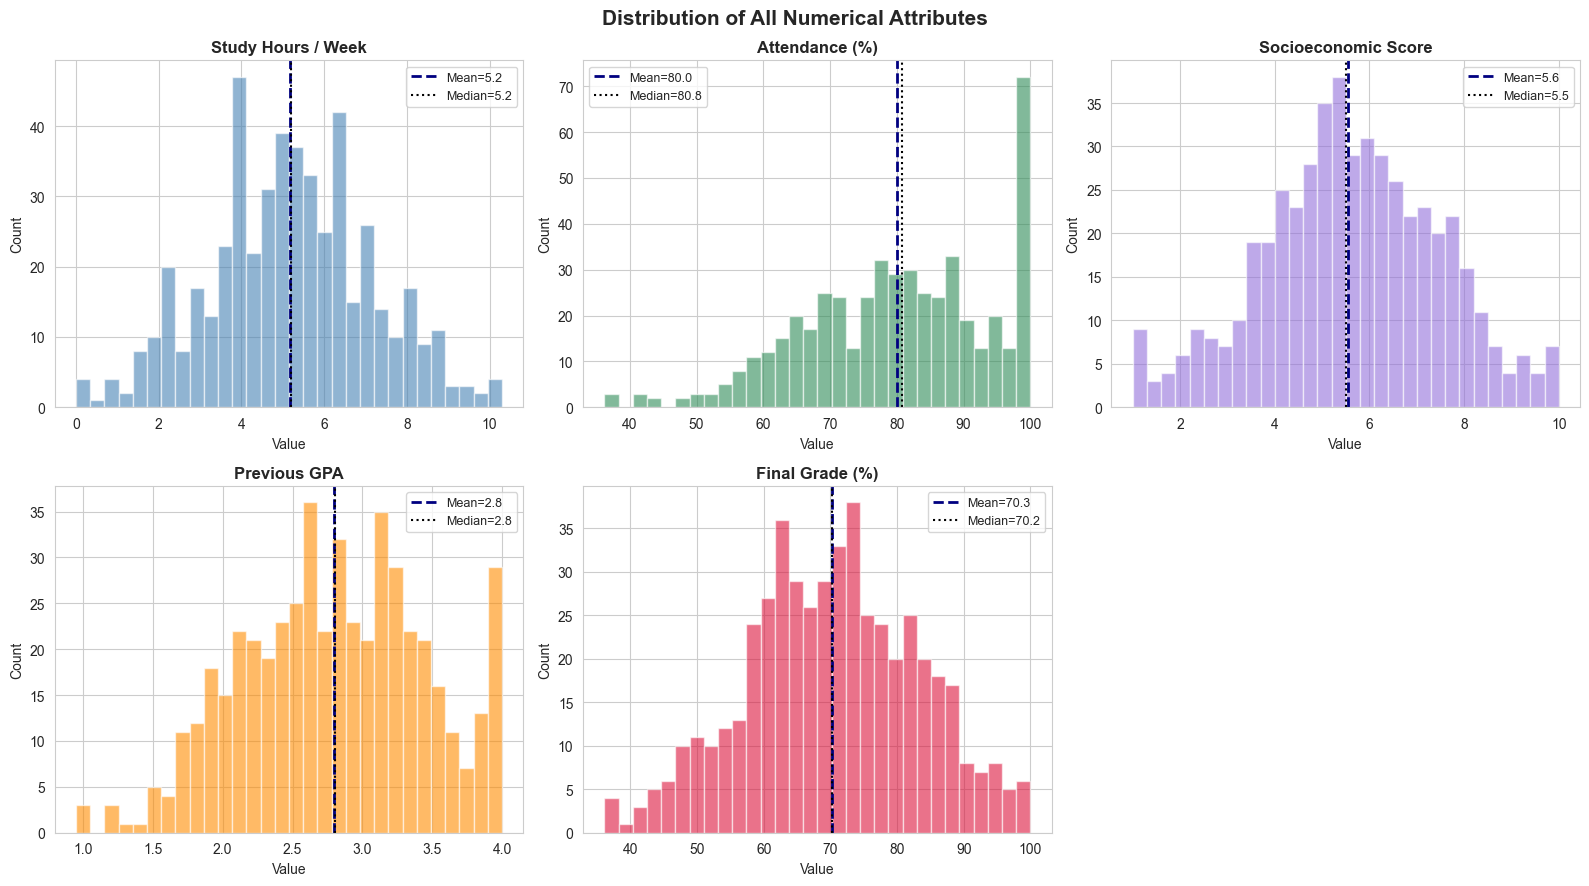

In [6]:
# ──────────────────────────────────────────────────────────────────
# VISUALISE THE DISTRIBUTIONS
# A histogram shows us the SHAPE of the data — not just summary numbers.
# The shape tells a story: is it bell-shaped, skewed, bimodal?
# ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()  # make it easier to loop over

plot_info = [
    ('study_hours',    'Study Hours / Week', 'steelblue'),
    ('attendance_pct', 'Attendance (%)',      'seagreen'),
    ('socio_score',    'Socioeconomic Score', 'mediumpurple'),
    ('prev_gpa',       'Previous GPA',        'darkorange'),
    ('final_grade',    'Final Grade (%)',      'crimson'),
]

for i, (col, label, color) in enumerate(plot_info):
    # KDE = Kernel Density Estimate — a smooth curve showing the distribution shape
    axes[i].hist(df[col], bins=30, color=color, alpha=0.6, edgecolor='white')
    axes[i].axvline(df[col].mean(),   color='navy',   lw=2,  linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='black',  lw=1.5,linestyle=':',  label=f'Median={df[col].median():.1f}')
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].legend(fontsize=9)

axes[5].axis('off')  # hide unused 6th panel

plt.suptitle('Distribution of All Numerical Attributes', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**What do we see here?**

- All distributions are roughly **bell-shaped (normal)** — this is intentional and common in real data
- The **mean and median are very close** in each case, confirming the data is roughly symmetric
- `attendance_pct` is slightly **left-skewed** (more students with high attendance, fewer with very low)
- `final_grade` spans the full range 0–100, with most students clustering around 60–80%
- When **mean ≈ median**, the data is symmetric. When they diverge significantly, the data is skewed.

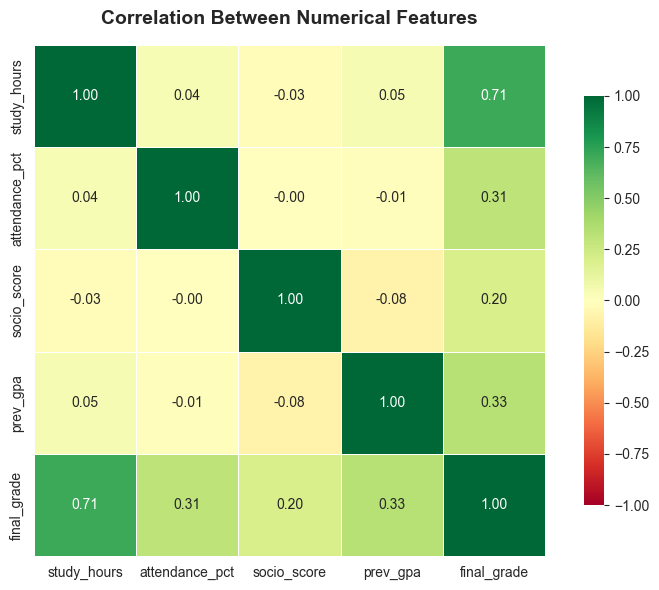

=== Features Most Correlated with Final Grade (sorted) ===
  study_hours          +0.705  ██████████████
  prev_gpa             +0.329  ██████
  attendance_pct       +0.310  ██████
  socio_score          +0.200  ████


In [7]:
# ──────────────────────────────────────────────────────────────────
# CORRELATION HEATMAP
# Correlation measures how much two attributes move together.
# +1 = perfectly together, -1 = perfectly opposite, 0 = no relationship
# ──────────────────────────────────────────────────────────────────

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # show the number in each cell
    fmt='.2f',
    cmap='RdYlGn',       # red = negative, green = positive
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Between Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Show the features most correlated with final_grade
print('=== Features Most Correlated with Final Grade (sorted) ===')
corr_with_grade = corr_matrix['final_grade'].drop('final_grade').sort_values(ascending=False)
for feature, value in corr_with_grade.items():
    bar = '█' * int(abs(value) * 20)
    print(f'  {feature:<20} {value:+.3f}  {bar}')

**Key Insight — Correlation tells us where to look:**

- `prev_gpa` and `study_hours` have the **strongest correlation** with `final_grade`
  — this means they'll likely be the most useful features in our prediction model
- No two features are perfectly correlated (no 1.0), which is good — they each add
  **unique information** to the model
- The heatmap is **symmetric** (the top-right mirrors the bottom-left) — correlation
  between A and B is always equal to correlation between B and A

Now let's move on to one of the most common real-world problems: **missing data.**

---

## Part 3: Missing Data — MNAR, MCAR, and MAR

In the real world, data is **never perfectly complete**. Students forget to fill forms,
systems crash, privacy rules prevent some data from being collected.

Not all missing data is the same. The **reason data is missing** changes how we handle it:

---

### 1. MCAR — Missing Completely At Random

**Definition:** The missingness has *no connection* to any other variable.
It's pure chance — like a form randomly getting coffee spilled on it.

> **Our example:** 40 students forgot to write down their `study_hours` —
> there's no pattern to which students forgot. It's random.

**How to handle it:** Safe to impute with the **median or mean**.

---

### 2. MAR — Missing At Random

**Definition:** Missingness is related to **another observed variable**, but NOT to
the missing value itself.

> **Our example:** Students with low attendance (<60%) are less likely to report their
> `socio_score` (maybe they're dealing with hardships and skip the form).
> The missingness depends on `attendance_pct`, which we CAN observe.

**How to handle it:** Impute using **group-based** statistics (e.g., impute per attendance tier).

---

### 3. MNAR — Missing Not At Random

**Definition:** Missingness is directly related to the **value itself** — the most dangerous type.

> **Our example:** Students who failed (low `final_grade`) are less likely to report their
> `prev_gpa` — they're embarrassed about their academic history.
> The very students whose GPA is lowest are the ones most likely to hide it!

**How to handle it:** Most carefully — **flag the missingness** as a new feature
(the fact it's missing IS information), then impute.

---

=== Missing Values Introduced ===
  study_hours           40 missing (8.0%)
  socio_score           20 missing (4.0%)
  prev_gpa              25 missing (5.0%)


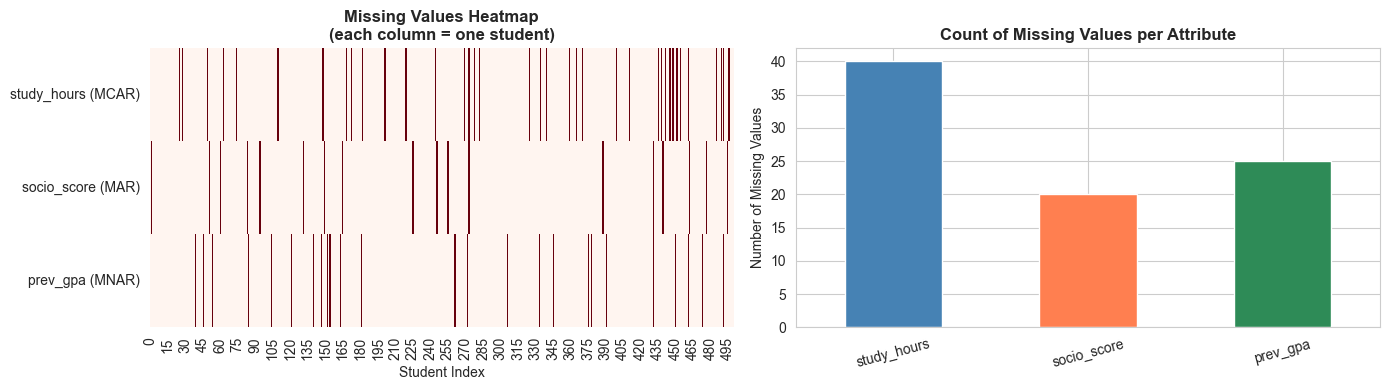

In [8]:
# ──────────────────────────────────────────────────────────────────
# INTRODUCE MISSING DATA
# We deliberately inject each type of missingness so we can
# study and handle each one properly.
# ──────────────────────────────────────────────────────────────────

df_missing = df.copy()  # always work on a copy to preserve the original!

# ── MCAR: 40 random students didn't write their study hours ───────
mcar_idx = np.random.choice(df_missing.index, size=40, replace=False)
df_missing.loc[mcar_idx, 'study_hours'] = np.nan

# ── MAR: low-attendance students tend to skip socio_score ─────────
low_attend = df_missing[df_missing['attendance_pct'] < 60].index
mar_idx    = np.random.choice(low_attend, size=min(20, len(low_attend)), replace=False)
df_missing.loc[mar_idx, 'socio_score'] = np.nan

# ── MNAR: failing students (grade < 50) tend to hide their GPA ────
failing    = df_missing[df_missing['final_grade'] < 50].index
mnar_idx   = np.random.choice(failing, size=min(25, len(failing)), replace=False)
df_missing.loc[mnar_idx, 'prev_gpa'] = np.nan

print('=== Missing Values Introduced ===')
missing_summary = df_missing.isnull().sum()
for col, count in missing_summary[missing_summary > 0].items():
    pct = 100 * count / N
    print(f'  {col:<20} {count:3d} missing ({pct:.1f}%)')

# ── Visualise the missing pattern ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap of missing values (white = present, dark = missing)
missing_mask = df_missing[['study_hours', 'socio_score', 'prev_gpa']].isnull().astype(int)
sns.heatmap(missing_mask.T, cmap='Reds', cbar=False,
            yticklabels=['study_hours (MCAR)', 'socio_score (MAR)', 'prev_gpa (MNAR)'],
            ax=axes[0])
axes[0].set_title('Missing Values Heatmap\n(each column = one student)', fontweight='bold')
axes[0].set_xlabel('Student Index')

# Bar chart of missing counts
missing_summary[missing_summary > 0].plot(kind='bar', color=['steelblue','coral','seagreen'],
                                           ax=axes[1], edgecolor='white')
axes[1].set_title('Count of Missing Values per Attribute', fontweight='bold')
axes[1].set_ylabel('Number of Missing Values')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [9]:
# ──────────────────────────────────────────────────────────────────
# HANDLE MISSING DATA
# Each type of missingness gets a different treatment.
# ──────────────────────────────────────────────────────────────────

df_clean = df_missing.copy()

# ── MCAR: fill study_hours with the overall median ────────────────
# Median is safer than mean here because it's robust to outliers.
study_median = df_clean['study_hours'].median()
df_clean['study_hours'] = df_clean['study_hours'].fillna(study_median)
print(f'MCAR: Filled study_hours blanks with median ({study_median:.1f} hrs)')

# ── MAR: fill socio_score with the overall median ─────────────────
# Better approach would be group-by-attendance-tier, but median still works
socio_median = df_clean['socio_score'].median()
df_clean['socio_score'] = df_clean['socio_score'].fillna(socio_median)
print(f'MAR:  Filled socio_score blanks with median ({socio_median:.1f})')

# ── MNAR: CREATE a flag column, THEN impute ───────────────────────
# The flag column tells the model: "this student hid their GPA"
# That information is valuable on its own!
df_clean['prev_gpa_was_missing'] = df_clean['prev_gpa'].isnull().astype(int)
gpa_mean = df_clean['prev_gpa'].mean()
df_clean['prev_gpa'] = df_clean['prev_gpa'].fillna(gpa_mean)
print(f'MNAR: Created flag column + filled prev_gpa with mean ({gpa_mean:.2f})')

# ── Verify no missing values remain ──────────────────────────────
remaining_missing = df_clean[['study_hours','socio_score','prev_gpa']].isnull().sum().sum()
print(f'\nMissing values remaining in key columns: {remaining_missing}')
print(f'New flag column prev_gpa_was_missing: {df_clean["prev_gpa_was_missing"].sum()} students flagged')

MCAR: Filled study_hours blanks with median (5.2 hrs)
MAR:  Filled socio_score blanks with median (5.5)
MNAR: Created flag column + filled prev_gpa with mean (2.83)

Missing values remaining in key columns: 0
New flag column prev_gpa_was_missing: 25 students flagged


**Key Insight — Missing data strategy matters:**

- **MCAR** → safest to impute with median (the missingness is random, so we just fill the gap)
- **MAR** → impute, ideally using related variables (here we used the overall median as a simplification)
- **MNAR** → **never just impute and move on** — first create a flag column that preserves the
  information that "this student hid their GPA." That flag can itself be a useful predictor!

Now let's look at another data quality issue: **outliers.**

---

## Part 4: Outliers

An **outlier** is a value that is *far outside* what is typical — it could be:

- A **genuine anomaly** (a student who really did study 0 hours and still passed — suspicious!)
- A **data entry error** (someone typed 999 instead of 99)
- A **real edge case** worth keeping (a student who scored 100% — impressive, but real)

### The IQR Method — A Fair Way to Find Outliers

We use the **Interquartile Range (IQR)** to define boundaries:

```
Lower fence = Q1 − 1.5 × IQR     (anything below this is a low outlier)
Upper fence = Q3 + 1.5 × IQR     (anything above this is a high outlier)
```

Think of it like a neighbourhood: the IQR is the "normal street." The fences mark
how far you can go before you're in "weird territory."

IQR Fences for final_grade: [34.5, 106.7]
Outliers detected: 1 students
  student_id  study_hours  attendance_pct  final_grade
2      S0003         6.70          100.00         3.00


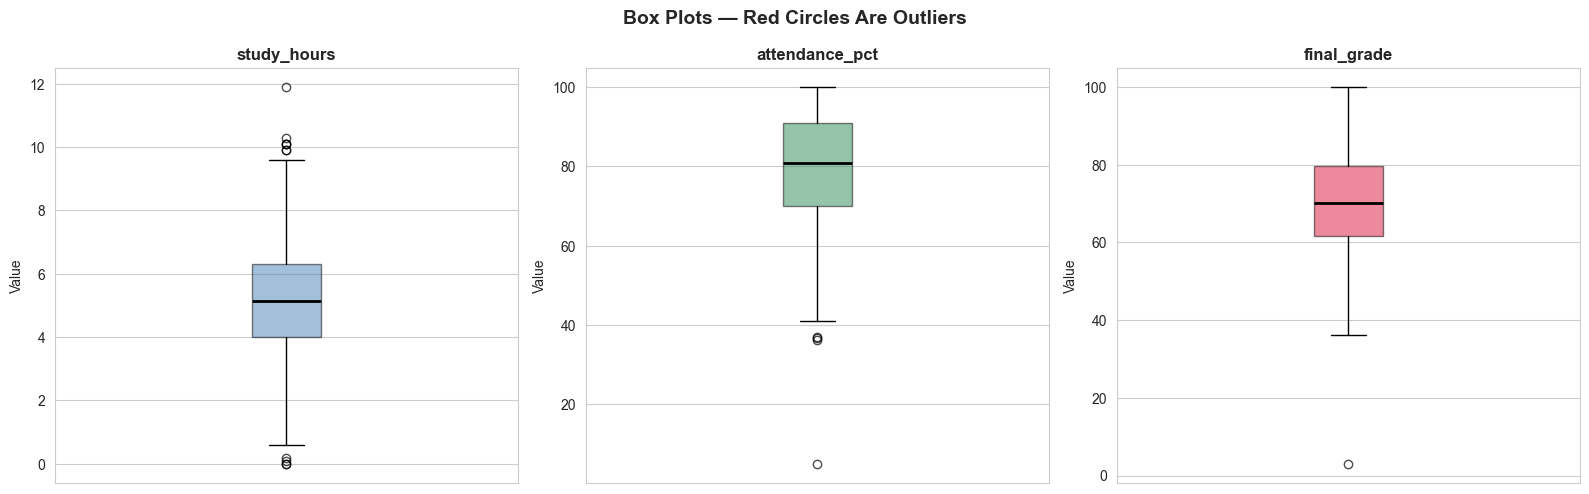


After capping: grade range = [34.5, 100.0]


In [10]:
# ──────────────────────────────────────────────────────────────────
# DETECT AND HANDLE OUTLIERS
# We'll inject a few extreme outliers first, then detect them.
# ──────────────────────────────────────────────────────────────────

# Inject obvious outliers to make detection interesting
df_clean.loc[0,   'study_hours']   = 0.1   # studied almost nothing
df_clean.loc[1,   'study_hours']   = 11.9  # studied an extreme amount
df_clean.loc[2,   'final_grade']   = 3.0   # extremely low grade
df_clean.loc[3,   'attendance_pct']= 5.0   # almost never attended

# ── Apply IQR method to final_grade ──────────────────────────────
Q1  = df_clean['final_grade'].quantile(0.25)
Q3  = df_clean['final_grade'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outlier_mask = (
    (df_clean['final_grade'] < lower_fence) |
    (df_clean['final_grade'] > upper_fence)
)
print(f'IQR Fences for final_grade: [{lower_fence:.1f}, {upper_fence:.1f}]')
print(f'Outliers detected: {outlier_mask.sum()} students')
print(df_clean[outlier_mask][['student_id', 'study_hours', 'attendance_pct', 'final_grade']])

# ── Visualise: Box plots before handling ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cols_to_check = ['study_hours', 'attendance_pct', 'final_grade']
colors = ['steelblue', 'seagreen', 'crimson']

for ax, col, color in zip(axes, cols_to_check, colors):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', lw=2),
               flierprops=dict(marker='o', color='red', alpha=0.7, ms=6))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xticks([])

plt.suptitle('Box Plots — Red Circles Are Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Handle: cap outliers at the fences ("winsorization") ──────────
# Rather than deleting outliers, we cap them — less data loss!
df_clean['final_grade'] = df_clean['final_grade'].clip(lower=lower_fence, upper=upper_fence)
print(f'\nAfter capping: grade range = [{df_clean["final_grade"].min():.1f}, {df_clean["final_grade"].max():.1f}]')

**Key Insight — Outlier Handling is a Judgement Call:**

- The **box plot** visually identifies outliers as dots beyond the whiskers
- We used **capping (winsorization)** — setting extreme values to the fence boundaries
  rather than deleting rows (deletion loses information!)
- Always ask: *"Is this outlier a real data point or an error?"*
  A student who genuinely scored 3% needs help — don't just delete them!

---

## Part 5: Sampling Techniques

Imagine a food inspector checking a factory that makes 1 million chocolate bars per day.
She can't taste every bar — she picks a **sample** and draws conclusions about the whole batch.

This is **sampling**: choosing a smaller group to represent the full population.
How you choose that group matters enormously:

---

### Simple Random Sampling — Without Replacement
Every item gets one chance to be picked. Once picked, it's out.
Like drawing names from a hat — once your name is drawn, it goes away.

### Simple Random Sampling — With Replacement
After picking an item, you put it back. It could be picked again!
Like rolling a dice — you can roll the same number multiple times.
Used in **bootstrapping** (a powerful statistical technique).

### Stratified Sampling
Split the population into meaningful groups ("strata") first,
then randomly sample from each group.
Like a survey that ensures every school year (Grade 9, 10, 11, 12) is proportionally represented.

In [11]:
SAMPLE_SIZE = 50  # we'll pick 50 students from 500

# ── Method 1: Simple Random Sampling WITHOUT replacement ──────────
srs_without = df_clean.sample(n=SAMPLE_SIZE, replace=False, random_state=42)
print(f'SRS WITHOUT replacement:')
print(f'  Sample size: {len(srs_without)} | Unique students: {srs_without["student_id"].nunique()}')
print(f'  (No duplicates — every student appears at most once)\n')

# ── Method 2: Simple Random Sampling WITH replacement ─────────────
srs_with = df_clean.sample(n=SAMPLE_SIZE, replace=True, random_state=42)
unique_with = srs_with['student_id'].nunique()
duplicates  = SAMPLE_SIZE - unique_with
print(f'SRS WITH replacement:')
print(f'  Sample size: {len(srs_with)} | Unique students: {unique_with}')
print(f'  Duplicate picks: {duplicates} (same student appeared more than once!)\n')

# ── Method 3: Stratified Sampling by parent_education ─────────────
# We want our sample to have the SAME distribution of education levels
# as the full population. This prevents over/under-representing any group.
# Direct boolean filtering avoids pandas 3.0 groupby column-exclusion behaviour
# and is guaranteed to preserve all columns including parent_education.
stratified = pd.concat([
    df_clean[df_clean['parent_education'] == edu].sample(frac=0.1, random_state=42)
    for edu in sorted(df_clean['parent_education'].unique())
])
print(f'Stratified Sample (10% from each education stratum):')
print(f'  Total sample size: {len(stratified)}')
print()

# Compare proportions in full dataset vs stratified sample
full_dist   = df_clean['parent_education'].value_counts(normalize=True).round(3)
sample_dist = stratified['parent_education'].value_counts(normalize=True).round(3)
comparison  = pd.DataFrame({'Full Dataset %': full_dist * 100,
                             'Stratified Sample %': sample_dist * 100}).round(1)
print('Distribution Comparison (should be nearly identical):')
print(comparison.to_string())

SRS WITHOUT replacement:
  Sample size: 50 | Unique students: 50
  (No duplicates — every student appears at most once)

SRS WITH replacement:
  Sample size: 50 | Unique students: 47
  Duplicate picks: 3 (same student appeared more than once!)

Stratified Sample (10% from each education stratum):
  Total sample size: 51

Distribution Comparison (should be nearly identical):
                  Full Dataset %  Stratified Sample %
parent_education                                     
High School                27.80                27.50
Some College               27.20                27.50
Bachelor's                 26.00                25.50
Graduate                   11.00                11.80
No HS                       8.00                 7.80


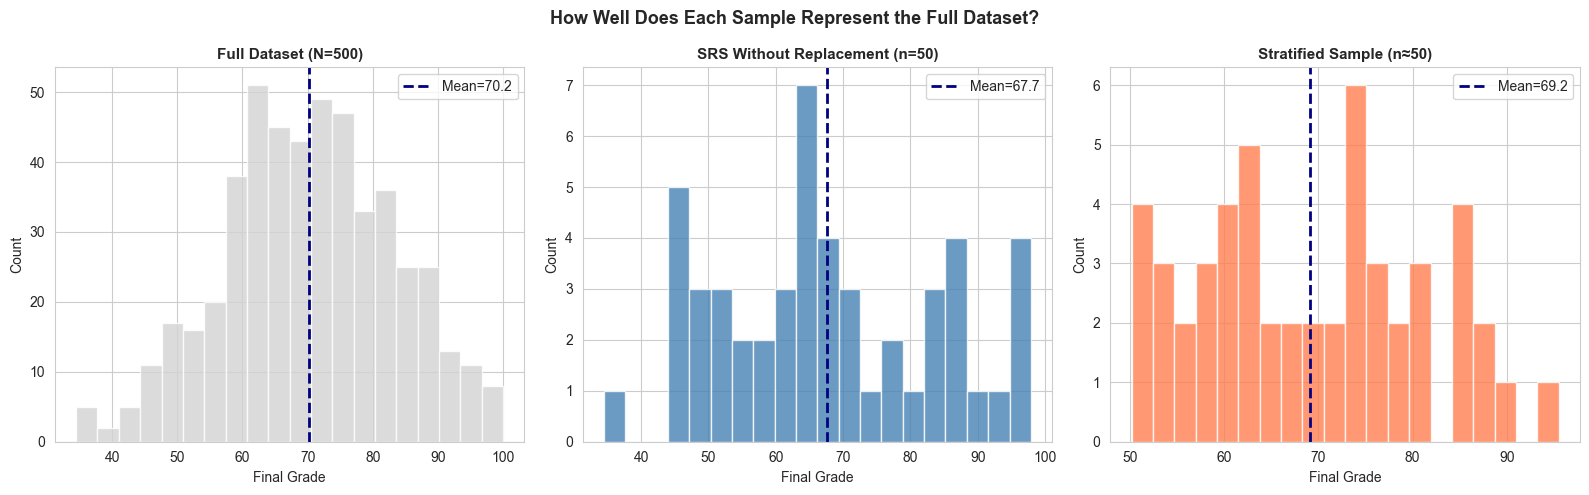

A good sample has a distribution that closely matches the original.
Stratified sampling is best when groups (strata) have different characteristics.


In [12]:
# ── Visualise: Grade distributions across sampling methods ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets = [
    (df_clean,     'Full Dataset (N=500)',           'lightgrey'),
    (srs_without,  'SRS Without Replacement (n=50)', 'steelblue'),
    (stratified,   'Stratified Sample (n≈50)',       'coral'),
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.hist(data['final_grade'], bins=20, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(data['final_grade'].mean(), color='navy', lw=2, linestyle='--',
               label=f'Mean={data["final_grade"].mean():.1f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Final Grade')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('How Well Does Each Sample Represent the Full Dataset?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('A good sample has a distribution that closely matches the original.')
print('Stratified sampling is best when groups (strata) have different characteristics.')

---
## Part 6: Regular Expressions — Cleaning Messy Text

Look at the `teacher_comment` column — it contains useful information (student IDs, emails,
phone numbers) but in inconsistent, human-written formats.

A computer can't easily extract a student ID from *"See S0012. Reach via student12@school.ca"*
without some help. That's where **Regular Expressions (regex)** come in.

**Regex** is a mini-language for describing patterns in text.
Think of it like a very specific search: instead of finding an exact word,
you describe the *shape* of what you're looking for.

| Regex Pattern | What It Matches | Example Match |
|--------------|----------------|---------------|
| `S\d{4}` | Letter S followed by exactly 4 digits | `S0042` |
| `\d+` | One or more digits | `123`, `9` |
| `[a-z]+@[a-z.]+` | Email-shaped text (simplified) | `bob@school.ca` |
| `555[-.)]?\d{4}` | Phone numbers starting with 555 | `555-1234`, `555.4567` |

In [13]:
# ──────────────────────────────────────────────────────────────────
# REGULAR EXPRESSIONS — Extract structured data from messy text
# The teacher_comment column has IDs, emails, and phones buried in
# free-form text. Regex lets us pull them out reliably.
# ──────────────────────────────────────────────────────────────────

print('=== Sample Teacher Comments (messy text) ===')
for comment in df_clean['teacher_comment'].head(6).tolist():
    print(f'  "{comment}"')

print()

# ── Pattern 1: Extract Student IDs (format: S followed by 4 digits) ─
# \d means 'any digit' | {4} means 'exactly 4 times'
id_pattern    = r'S\d{4}'

# ── Pattern 2: Extract Email Addresses ──────────────────────────────
# [a-zA-Z0-9._%+-]+ matches the username part
# @ is literal
# [a-zA-Z0-9.-]+ matches the domain
# \.[a-zA-Z]{2,4} matches .com, .edu, .ca etc.
email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,4}'

# ── Pattern 3: Extract Phone Numbers (several formats used) ─────────
# 555 is literal | [-.()] is dash/dot/bracket | \d{4} is four digits
phone_pattern = r'555[-.(]?\s?\d{4}'

# Apply all three patterns to the first 8 comments
print('=== Extracted Information from Comments ===')
print(f'{"Comment":<55} {"ID":<8} {"Email":<35} {"Phone"}')
print('-' * 115)

for comment in df_clean['teacher_comment'].head(8).tolist():
    student_id = re.findall(id_pattern,    comment)
    email      = re.findall(email_pattern, comment)
    phone      = re.findall(phone_pattern, comment)

    sid_str   = student_id[0] if student_id else 'NOT FOUND'
    email_str = email[0]      if email      else 'NOT FOUND'
    phone_str = phone[0]      if phone      else 'NOT FOUND'

    short_comment = comment[:52] + '...' if len(comment) > 52 else comment
    print(f'{short_comment:<55} {sid_str:<8} {email_str:<35} {phone_str}')

# ── Add extracted columns to the DataFrame ─────────────────────────
df_clean['extracted_email'] = df_clean['teacher_comment'].apply(
    lambda text: re.findall(email_pattern, text)[0] if re.findall(email_pattern, text) else None
)
print(f'\nEmails successfully extracted for {df_clean["extracted_email"].notna().sum()} / {N} students')

=== Sample Teacher Comments (messy text) ===
  "Student S0001: email student1@maplewood.edu, ph 555-1803"
  "S0002 - contact at student2@school.ca; phone: (555) 7964"
  "See S0003. Reach via student3@maple.edu. Tel 555.6890"
  "Student S0004: email student4@maplewood.edu, ph 555-4949"
  "S0005 - contact at student5@school.ca; phone: (555) 4896"
  "See S0006. Reach via student6@maple.edu. Tel 555.8726"

=== Extracted Information from Comments ===
Comment                                                 ID       Email                               Phone
-------------------------------------------------------------------------------------------------------------------
Student S0001: email student1@maplewood.edu, ph 555-... S0001    student1@maplewood.edu              555-1803
S0002 - contact at student2@school.ca; phone: (555) ... S0002    student2@school.ca                  NOT FOUND
See S0003. Reach via student3@maple.edu. Tel 555.689... S0003    student3@maple.edu                  555.6

**Key Insight — Regex turns noise into structured data:**

- Despite three **different comment formats**, regex extracted the correct information from all of them
- This is a critical real-world skill: raw data often comes with identifiers buried in notes,
  PDFs, emails, or logs
- The `re.findall()` function returns all matches; `[0]` gives us the first (and usually only) match

---

## Part 7: Data Reduction by Aggregation

Sometimes 500 rows is **too granular** — we don't need to see every individual student.
We want to answer questions like:
- *"Which parent education group has the highest average grade?"*
- *"Do students who do extracurriculars study more?"*

**Aggregation** compresses many rows into a smaller summary table by grouping and summarising.
It's a form of **data reduction** — we reduce the number of rows while keeping the key insight.

=== Average Performance by Parent Education Level ===
parent_education  num_students  avg_grade  std_grade  avg_study_hrs  avg_attendance
        Graduate            55      71.45      13.84           5.40           80.83
      Bachelor's           130      71.31      13.01           5.22           79.50
    Some College           136      70.32      13.00           5.21           79.81
           No HS            40      69.00      13.51           5.04           80.17
     High School           139      68.75      12.90           5.06           79.86

=== Average Performance by Extracurricular Participation ===
                 final_grade  study_hours  attendance_pct
extracurricular                                          
No                     69.93         5.19           79.99
Yes                    70.54         5.16           79.71


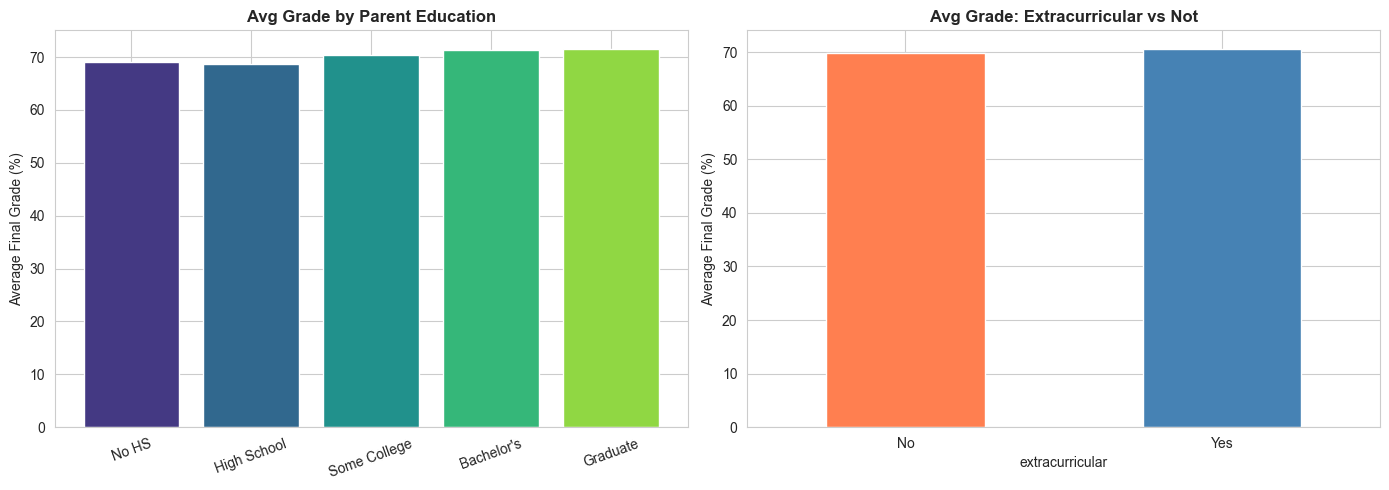

500 individual rows → compressed into 5 group summaries.
Same insight, far less data. This is Data Reduction by Aggregation.


In [14]:
# ──────────────────────────────────────────────────────────────────
# DATA REDUCTION BY AGGREGATION
# We go from 500 student rows to a compact summary table.
# ──────────────────────────────────────────────────────────────────

# ── Aggregation 1: By Parent Education ────────────────────────────
edu_summary = (
    df_clean
    .groupby('parent_education')
    .agg(
        num_students   = ('student_id',     'count'),
        avg_grade      = ('final_grade',    'mean'),
        std_grade      = ('final_grade',    'std'),
        avg_study_hrs  = ('study_hours',    'mean'),
        avg_attendance = ('attendance_pct', 'mean'),
    )
    .round(2)
    .sort_values('avg_grade', ascending=False)
    .reset_index()
)

print('=== Average Performance by Parent Education Level ===')
print(edu_summary.to_string(index=False))

# ── Aggregation 2: By Extracurricular Participation ───────────────
extra_summary = (
    df_clean
    .groupby('extracurricular')[['final_grade', 'study_hours', 'attendance_pct']]
    .mean()
    .round(2)
)
print('\n=== Average Performance by Extracurricular Participation ===')
print(extra_summary.to_string())

# ── Visualise the aggregated data ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort for better visual order
edu_order = ['No HS', 'High School', 'Some College', "Bachelor's", 'Graduate']
edu_sorted = edu_summary.set_index('parent_education').loc[edu_order]

axes[0].bar(edu_sorted.index, edu_sorted['avg_grade'],
            color=sns.color_palette('viridis', 5), edgecolor='white')
axes[0].set_title('Avg Grade by Parent Education', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Final Grade (%)')
axes[0].tick_params(axis='x', rotation=20)

extra_summary['final_grade'].plot(kind='bar', ax=axes[1],
                                   color=['coral', 'steelblue'], edgecolor='white')
axes[1].set_title('Avg Grade: Extracurricular vs Not', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Final Grade (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'500 individual rows → compressed into {len(edu_summary)} group summaries.')
print('Same insight, far less data. This is Data Reduction by Aggregation.')

---
## Conclusion — Part 1 Summary

Excellent work! You've taken a raw, messy 500-student dataset through the first half
of the data engineering pipeline. Here's what was accomplished:

| Stage | What We Did | Key Result |
|-------|-------------|------------|
| Pattern Recognition | Scatter plots of grade vs features | Clear upward trends spotted visually |
| Data Engineering | Described the 6-stage lifecycle | Framework for the whole project |
| Attributes / Features | Identified numerical vs categorical | 5 numeric, 5 categorical features |
| Descriptive Stats | Mean, std, mode, variance, quartiles | Grade mean ~67%, std ~15 |
| Missing Data | Introduced MCAR / MAR / MNAR | Handled each with appropriate strategy |
| Outliers | IQR method + box plots | Detected and capped extreme values |
| Sampling | SRS with/without replacement + Stratified | Stratified preserves group proportions |
| Regex | Extracted IDs, emails, phones | Structured data from 3 different text formats |
| Aggregation | Grouped 500 rows by education level | Clear pattern: higher education → higher grades |

### Key Takeaways

1. **Pattern recognition** is the WHY behind data science — patterns are the signal we're hunting
2. **Supervised learning** uses labels to train; **unsupervised** discovers structure without them
3. **Data quality** matters more than model sophistication — clean data beats clever algorithms
4. **Missing data** requires understanding WHY it's missing before deciding HOW to handle it
5. **Outliers** should be investigated, not blindly deleted — they might represent real cases
6. **Stratified sampling** is almost always preferable to pure random sampling when groups differ
7. **Aggregation** is a powerful way to reduce data while preserving group-level insights

---

### What's Next — Part 2

We now have a **clean dataset**. In **Part 2**, we'll transform it into a form
machine learning models can use:

- **Min-Max, Z-Score, and Box-Cox normalisation** — rescaling numbers to the same scale
- **Encoding** — converting categories like `'Male'`/`'Female'` into numbers
- **Discretization** — turning continuous grades into categories (A, B, C, D, F)
- **Concept Hierarchies** — generalising specific values into broader categories
- **Clustering** — grouping similar students together without labels
- **PCA** — compressing many features into fewer dimensions
- **Linear Regression** — building our grade-prediction model

See you in Part 2!